In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns
df = pd.read_csv("/Users/athipongjindaphram/Documents/Python For DA/data_jobs.csv")
#Cleaning Date Column -> Type : Date time
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [26]:
df_da_us = df[
    (df["job_country"] == "United States")
    & 
    (df["job_title_short"] == "Data Analyst")
    ]

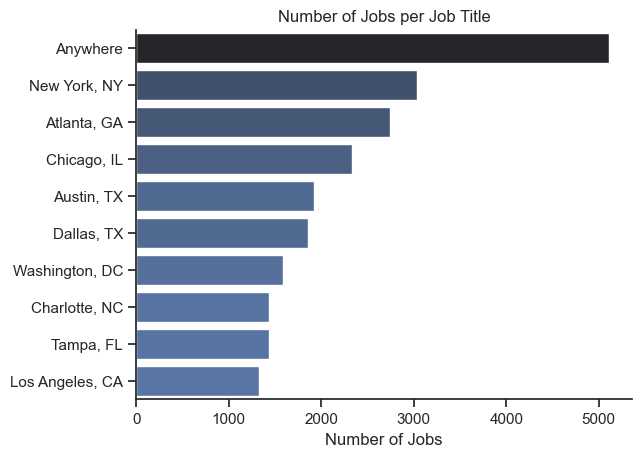

In [43]:
df_plot = df_da_us["job_location"].value_counts().head(10).reset_index()
df_plot
sns.set_theme(style="ticks")
sns.barplot(data=df_plot, x="job_location", y="index", hue="job_location", palette="dark:b_r", legend=False)
sns.despine()
plt.title("Number of Jobs per Job Title")
plt.xlabel("Number of Jobs")
plt.ylabel("")
plt.show()

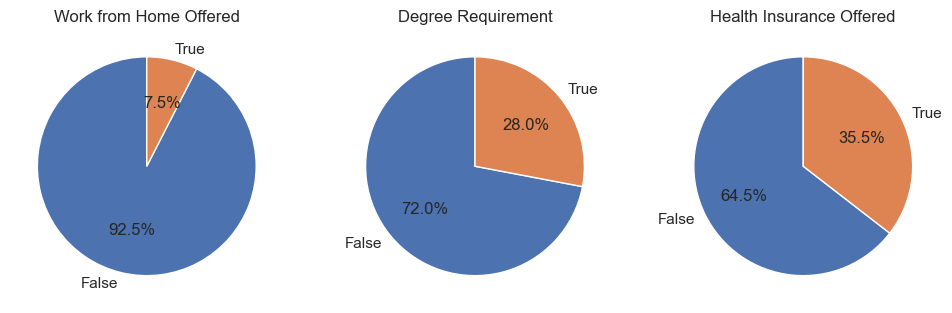

In [45]:
dict_column = {
    "job_work_from_home" : "Work from Home Offered",
    "job_no_degree_mention" : "Degree Requirement",
    "job_health_insurance" : "Health Insurance Offered"
}

fig, ax = plt.subplots(1,3)
fig.set_size_inches((12,5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_da_us[column].value_counts(), labels=["False", "True"], autopct="%1.1f%%", startangle=90)
    ax[i].set_title(title)

plt.show()

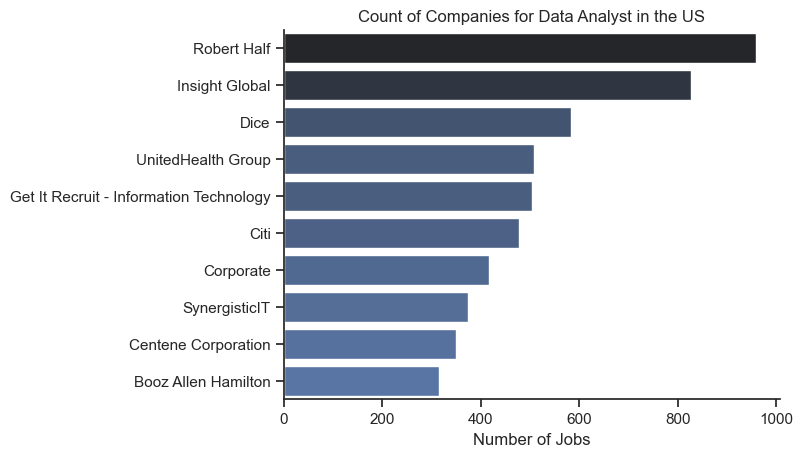

In [46]:
df_plot = df_da_us["company_name"].value_counts().head(10).reset_index()
df_plot
sns.set_theme(style="ticks")
sns.barplot(data=df_plot, x="company_name", y="index", hue="company_name", palette="dark:b_r", legend=False)
sns.despine()
plt.title("Count of Companies for Data Analyst in the US")
plt.xlabel("Number of Jobs")
plt.ylabel("")
plt.show()